<a href="https://colab.research.google.com/github/kimjunyeop05/junyeop/blob/main/%5BAI2025_Assignment%5D_CIFAR10_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR10 Classification

## Import Packages

In [1]:
import sys
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

### Data Preparation
Use CIFAR10 handwriting dataset

In [2]:
cifar10 = tf.keras.datasets.cifar10

Prepare data for training

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = tf.keras.utils.to_categorical(y_train.reshape(-1), 10)
y_test  = tf.keras.utils.to_categorical(y_test.reshape(-1), 10)


# Compile and Train neural network

## CNN Modeling
Create a convolutional neural network

### Goal

Improve the provided basic CNN model and achieve CIFAR-10 **test accuracy ≥ 75%**.


Modify the network architecture!

In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(128, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(128, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(256, 3, padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])


# Compile and Train neural network

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2)
]

history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=2
)


Epoch 1/30
352/352 - 21s - 60ms/step - accuracy: 0.7786 - loss: 0.6561 - val_accuracy: 0.7828 - val_loss: 0.6299 - learning_rate: 1.0000e-03
Epoch 2/30
352/352 - 16s - 46ms/step - accuracy: 0.7875 - loss: 0.6286 - val_accuracy: 0.7792 - val_loss: 0.6520 - learning_rate: 1.0000e-03
Epoch 3/30
352/352 - 21s - 59ms/step - accuracy: 0.7943 - loss: 0.6071 - val_accuracy: 0.7832 - val_loss: 0.6467 - learning_rate: 1.0000e-03
Epoch 4/30
352/352 - 16s - 46ms/step - accuracy: 0.8122 - loss: 0.5553 - val_accuracy: 0.7702 - val_loss: 0.7176 - learning_rate: 5.0000e-04
Epoch 5/30
352/352 - 16s - 46ms/step - accuracy: 0.8185 - loss: 0.5332 - val_accuracy: 0.7884 - val_loss: 0.6485 - learning_rate: 5.0000e-04
Epoch 6/30
352/352 - 16s - 46ms/step - accuracy: 0.8297 - loss: 0.5074 - val_accuracy: 0.8382 - val_loss: 0.4826 - learning_rate: 2.5000e-04
Epoch 7/30
352/352 - 16s - 45ms/step - accuracy: 0.8311 - loss: 0.4944 - val_accuracy: 0.8248 - val_loss: 0.5026 - learning_rate: 2.5000e-04
Epoch 8/30
35

## Evaluate neural network performance


In [9]:
model.evaluate(x_test,  y_test, verbose=2)

313/313 - 2s - 6ms/step - accuracy: 0.8437 - loss: 0.4594


[0.45941996574401855, 0.8436999917030334]

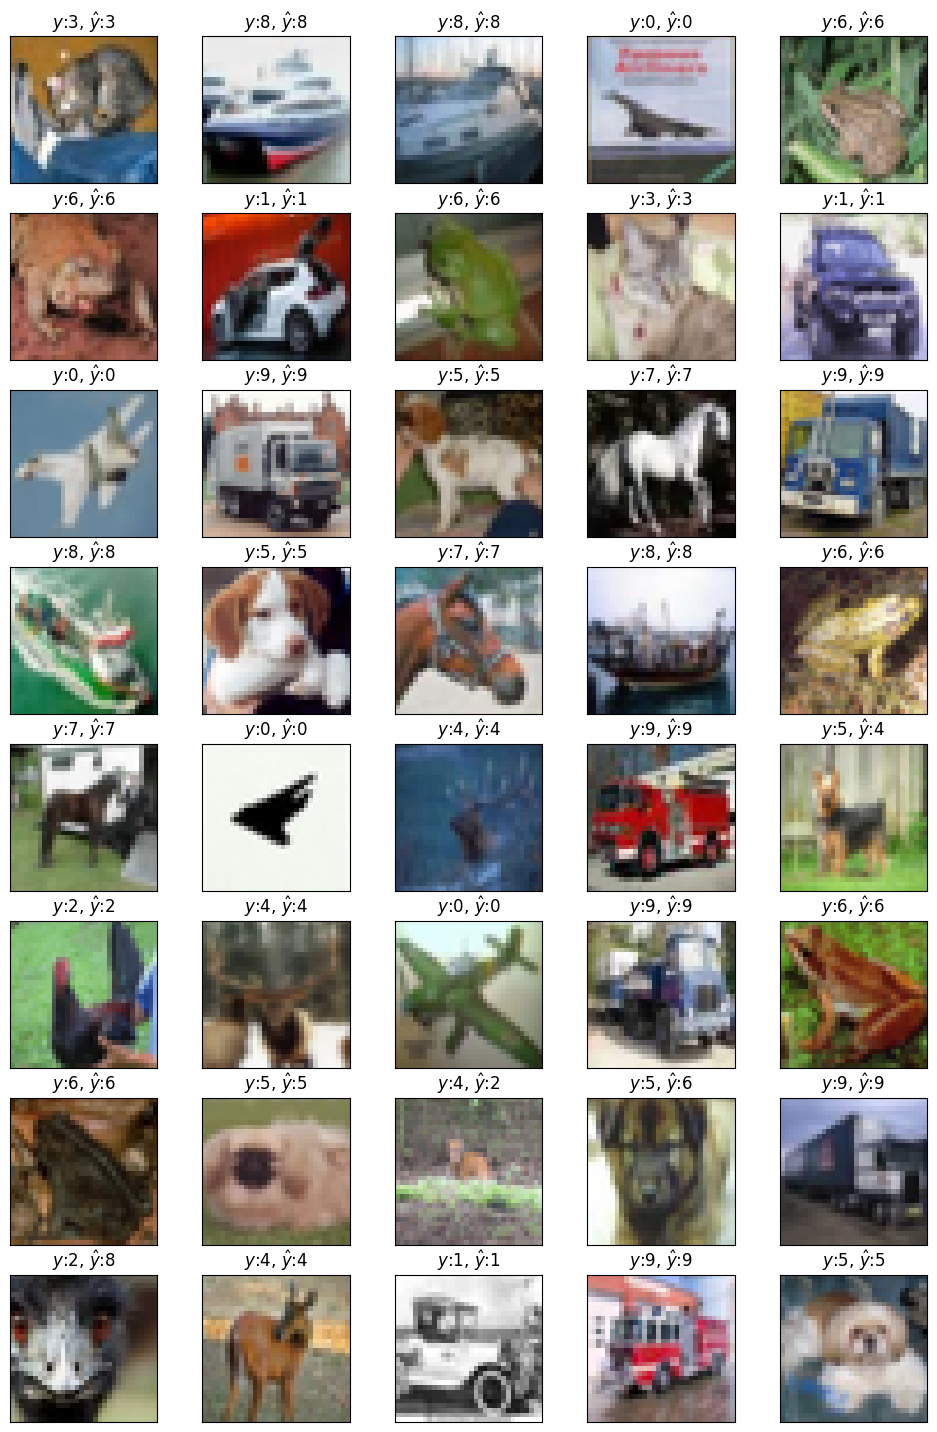

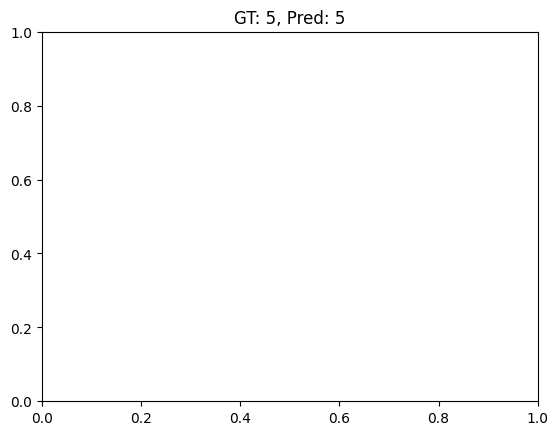

In [10]:
prob = model.predict(x_test[0:40], verbose=0)
pred = tf.argmax(prob, axis=1)

fig = plt.figure(figsize=(12, 18))
for i in range(40):
    subplot = fig.add_subplot(8, 5, i + 1)
    subplot.set_xticks([])
    subplot.set_yticks([])
    string = r'$\hat{y}$'
    subplot.set_title(f'$y$:{tf.argmax(y_test[i])}, {string}:{pred[i].numpy()}')
    subplot.imshow(tf.squeeze(x_test[i]))
plt.show()
true_label = tf.argmax(y_test[i]).numpy()
pred_label = pred[i].numpy()
plt.title(f"GT: {true_label}, Pred: {pred_label}")
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

In [11]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print("Test Accuracy:", accuracy)


Test Accuracy: 0.8436999917030334
